In [1]:
# Today's topic: importance of accessibility; intermediate-level coding in matplotcollab
# 
# Accessibity:
# E.g., "Daily Routines of Famous Creative People"
    # Good because: it includes a data source, appropriate plot type for comparison, limited colour pallette
    # BUT Sarah Fossheim tested it for accessibility to people with colour-blindness, and it actually wasn't accessible
# 
# E.g., "Flattening the curve" figure
    # Inaccessible features include small font; the immediate interventions callout is red, which may not stand out to colourblind people; 
    # because the figure is a raster, its text cannot be read easily by text-reading software   
# How to increase accessibility
    # Colour 
            # Defined by luminance, saturation (understood as ordered [e.g., on a scale]), and hue (very helpful for categories)
            # Viridis package can be used in python as a colour map 
        # Mark size has an impact on colour (e.g., more saturation on smaller ojects)
        # Brightness and contrast are important: high contrast between dark and bright wherever possible (WebAIM assesses accessibility of contrast)
    # Text
        # Every visualization in a visualization should be clearly explained in a legend
        # There is no single right typeface, but sans serif fonts are generally more accessible for people with dyslexia and other cognitive issues
        # Texts should usually be minimum 24pt font for presentations
    # Describing visualizations
        # Include alternate text that describes all important info within an image, written plainly and concisely where possible
        # Four types of descriptive content:
            # 1. Basic elements
            # 2. Descriptive statistics
            # 3. Trends, pattern synthesis, and other perceptual interpretations
            # 4. Context and domain insights: highly subjective interps that go beyond the data   
            # Levels 2 and 3 are generally most informative        

In [3]:
# Matplotlib live-coding

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [ ]:
# Create a random, reproducible dataset

np.random.seed(613)
x1= np.arange(50)
y1=np.random.randint(0, 75, 50)
x2=np.array(["Luffy","Zoro","Nami","Usopp", "Sanji"])
y2=np.array([110,180,240,99,220])

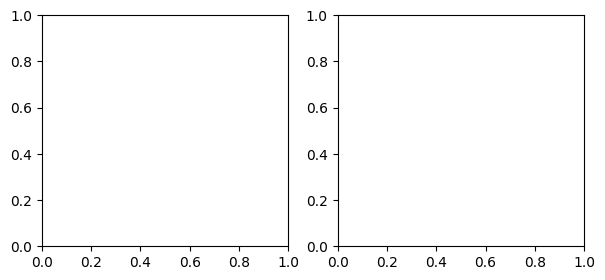

In [6]:
# Now we want two plots next to each other:

fig, (ax1, ax2) = plt.subplots(ncols=2,
                               nrows=1,
                               figsize=(7,3)) 

C:\Users\Kyle\AppData\Local\Temp\ipykernel_36436\2825013172.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


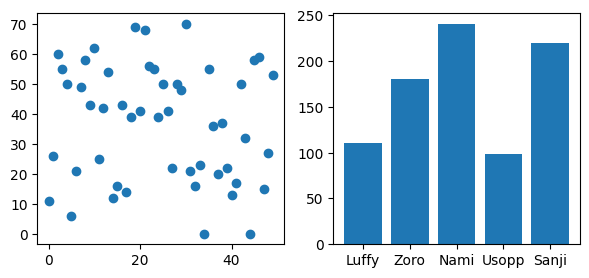

In [7]:
# Create scatterplot and bar plot:

fig, (ax1, ax2) = plt.subplots(ncols=2,
                               nrows=1,
                               figsize=(7,3)) 

ax1.scatter(x1, y1)
ax2.bar(x2,y2)
fig.show()

C:\Users\Kyle\AppData\Local\Temp\ipykernel_36436\338489960.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


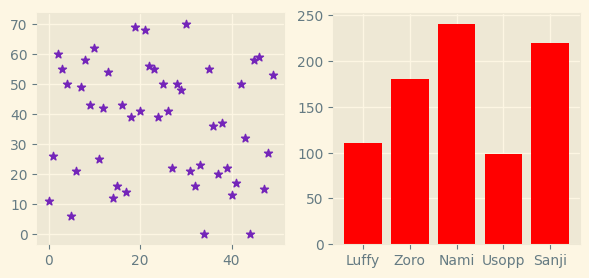

In [9]:
# Customize plot as you like:

plt.style.use('Solarize_Light2')

fig, (ax1, ax2) = plt.subplots(ncols=2,
                               nrows=1,
                               figsize=(7,3)) 

ax1.scatter(x1, y1, marker='*',color='#7425b9')
ax2.bar(x2,y2,color='red')
fig.show()

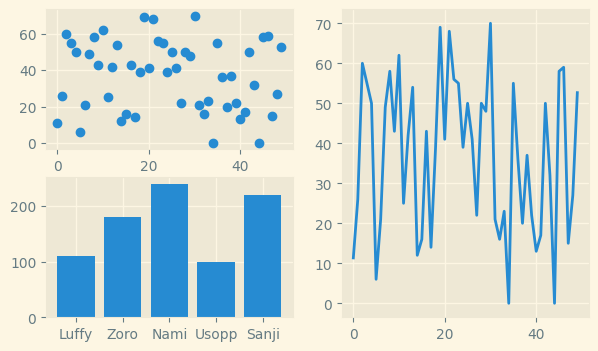

In [11]:
# Mosaic-based figure of multiple axes

fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                     ['ax2', 'ax3']], 
                                     figsize=(7, 4))

someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
plt.show()

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

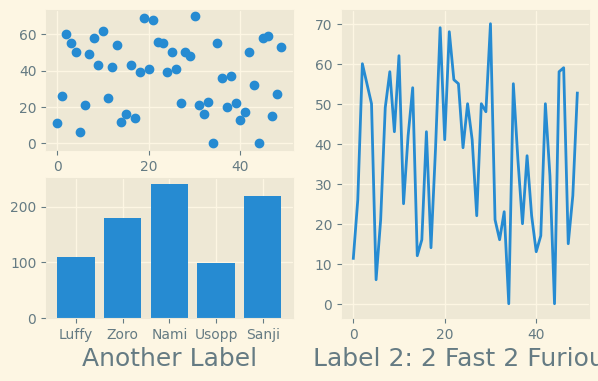

In [12]:
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                     ['ax2', 'ax3']], 
                                     figsize=(7, 4))

someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
someaxes["ax1"].set_xlabel('A Big Label', fontsize=18)
someaxes["ax2"].set_xlabel('Another Label', fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious',fontsize=18 )

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

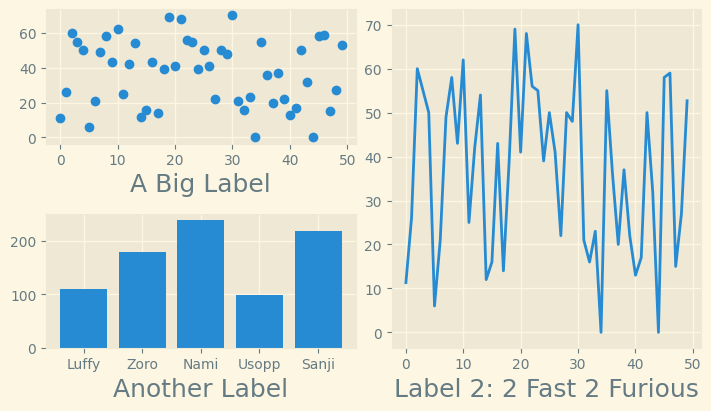

In [14]:
# Can add a constraint layout argument to assure that text is automatically adjusted

fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                     ['ax2', 'ax3']], 
                                     figsize=(7, 4),
                                     layout="constrained") #This line constrains the font

someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
someaxes["ax1"].set_xlabel('A Big Label', fontsize=18)
someaxes["ax2"].set_xlabel('Another Label', fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious',fontsize=18 )

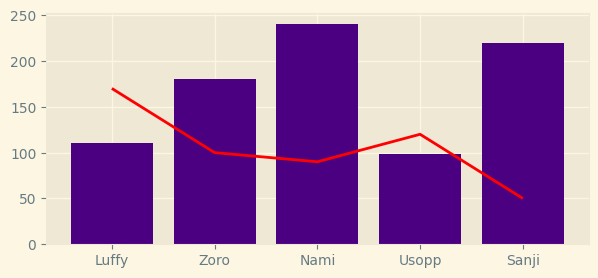

In [16]:
# Apply multiple vizualizations to one axis object

# make sample data
x = np.array(["Luffy", "Zoro", "Nami","Usopp", "Sanji"])
y1 = np.array([110,180,240,99,220])
y2 = np.array([170, 100, 90, 120, 50])

#define figure and axes
fig, ax = plt.subplots(figsize=(7,3))

# Call both bar and plot elements to the same axes
ax.bar(x,y1,
       color = "indigo")
ax.plot(x, y2,
        color = "red")

<ErrorbarContainer object of 3 artists>

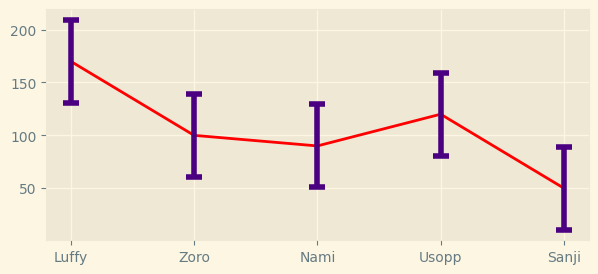

In [17]:
# Add error data (e.g., Standard Deviation)

y2_sd = np.std(y2)

fig, ax =plt.subplots(figsize=(7,3))
ax.plot(x,y2,
        color="red")
ax.errorbar(x,
            y2,
            yerr = y2_sd,
            fmt = "none",
            ecolor = "indigo",
            elinewidth = 4,
            capsize = 6,
            capthick = 4)

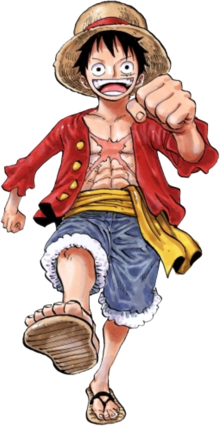

In [ ]:
# Now we're moving onto adding images to visualizations

from PIL import Image
import requests
from io import BytesIO

url = "https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png"

headers = {  #These headers keep your system from banning access to the hyperlink
    "User-Agent": "Mozilla/5.0",
    "Accept": "image/*,*/*;q=0.8",
    "Referer": "https://en.wikipedia.org/"
}

response=requests.get(url,headers=headers)
image_file=BytesIO(response.content)
image=Image.open(image_file)
image

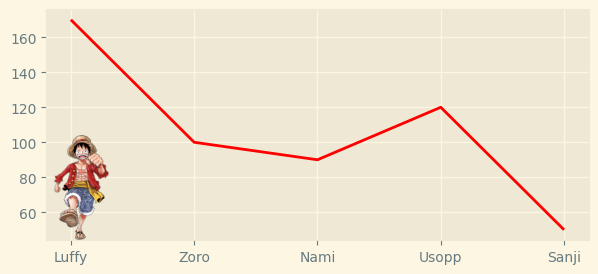

In [ ]:
# Add an image to a plot

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")

ax_image = fig.add_axes([0.1, # x coordinate (ON FIGURE, NOT AXES) 
                         0.11, # y coordinate (ON FIGURE, NOT AXES) 
                         0.15, # image width 
                         0.35]) # image height)

ax_image.imshow(image) #adds image to container created above
ax_image.axis('off') # removes messy axes from image


# Save the figure
path = 'G:/1_DSI_Certificate/Visualization'
filename = '/fig1a.png'
plt.savefig(path+filename, dpi=300)
